<a href="https://colab.research.google.com/github/anu-006/Retail_Sales_Predictor/blob/main/Big_Mart_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Understanding Data

In [369]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer



from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

!pip install xgboost
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score


In [370]:
data=pd.read_csv('Train.csv')
data

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [371]:
from datetime import datetime
data['Outlet_Age'] = datetime.now().year - data['Outlet_Establishment_Year']

In [372]:
data=data.drop(columns='Outlet_Establishment_Year')

In [373]:
data.shape

(8523, 12)

In [374]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Item_Identifier       8523 non-null   object 
 1   Item_Weight           7060 non-null   float64
 2   Item_Fat_Content      8523 non-null   object 
 3   Item_Visibility       8523 non-null   float64
 4   Item_Type             8523 non-null   object 
 5   Item_MRP              8523 non-null   float64
 6   Outlet_Identifier     8523 non-null   object 
 7   Outlet_Size           6113 non-null   object 
 8   Outlet_Location_Type  8523 non-null   object 
 9   Outlet_Type           8523 non-null   object 
 10  Item_Outlet_Sales     8523 non-null   float64
 11  Outlet_Age            8523 non-null   int64  
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [375]:
data.isnull().mean()

,0
Item_Identifier,0.000000
Item_Weight,0.171653
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Size,0.282764
Outlet_Location_Type,0.000000
Outlet_Type,0.000000


In [376]:
data['Outlet_Identifier'].value_counts()

,count
Outlet_Identifier,
OUT027,935
OUT013,932
OUT035,930
OUT049,930
OUT046,930
OUT045,929
OUT018,928
OUT017,926
OUT010,555


In [377]:
data.shape

(8523, 12)

In [378]:
data.duplicated().mean()

np.float64(0.0)

In [379]:
data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Outlet_Age
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,2181.288914,28.168133
std,4.643456,0.051598,62.275067,1706.499616,8.371760
min,4.555000,0.000000,31.290000,33.290000,17.000000
25%,8.773750,0.026989,93.826500,834.247400,22.000000
50%,12.600000,0.053931,143.012800,1794.331000,27.000000
75%,16.850000,0.094585,185.643700,3101.296400,39.000000
max,21.350000,0.328391,266.888400,13086.964800,41.000000


In [380]:
data.cov(numeric_only=True)

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Outlet_Age
Item_Weight,21.561688,-0.003172,7.865693,1.005608e+02,0.354551
Item_Visibility,-0.003172,0.002662,-0.004225,-1.132561e+01,0.032325
Item_MRP,7.865693,-0.004225,3878.183909,6.031749e+04,-2.617143
Item_Outlet_Sales,100.560811,-11.325611,60317.485612,2.912141e+06,701.962133
Outlet_Age,0.354551,0.032325,-2.617143,7.019621e+02,70.086372


In [381]:
data.corr(numeric_only=True)

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Outlet_Age
Item_Weight,1.000000,-0.014048,0.027141,0.014123,0.011588
Item_Visibility,-0.014048,1.000000,-0.001315,-0.128625,0.074834
Item_MRP,0.027141,-0.001315,1.000000,0.567574,-0.005020
Item_Outlet_Sales,0.014123,-0.128625,0.567574,1.000000,0.049135
Outlet_Age,0.011588,0.074834,-0.005020,0.049135,1.000000


In [382]:
data['Item_Identifier'].value_counts()

,count
Item_Identifier,
FDW13,10
FDG33,10
FDX31,9
FDT07,9
NCY18,9
...,...
FDO33,1
FDK57,1
FDT35,1


In [383]:
data=data.drop(columns=['Item_Identifier'])

In [384]:
data['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [385]:
def func(fat_type):
  if fat_type =='Low Fat' or fat_type =='LF' or fat_type =='low fat':
    return 'Low fat'
  else:
    return 'Regular'



In [386]:
data['Item_Fat_Content']=data['Item_Fat_Content'].apply(func)

In [387]:
data['Item_Type'].value_counts()

,count
Item_Type,
Fruits and Vegetables,1232
Snack Foods,1200
Household,910
Frozen Foods,856
Dairy,682
Canned,649
Baking Goods,648
Health and Hygiene,520
Soft Drinks,445


In [388]:
data['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


In [389]:
data['Outlet_Location_Type'].value_counts()

,count
Outlet_Location_Type,
Tier 3,3350
Tier 2,2785
Tier 1,2388


In [390]:
data['Outlet_Type'].value_counts()

,count
Outlet_Type,
Supermarket Type1,5577
Grocery Store,1083
Supermarket Type3,935
Supermarket Type2,928


In [391]:
def func_mrp(x):
  if x < 69:
        return "Low"
  elif x < 136:
        return "Medium"
  elif x < 203:
        return "High"
  else:
        return "Very High"

data["Item_MRP_Bucket"] = data["Item_MRP"].apply(func_mrp)

In [392]:

def bucket_visibility(x):
    if x < 0.05:
        return "Low"
    elif x < 0.1:
        return "Medium"
    elif x < 0.2:
        return "High"
    else:
        return "Very High"

data["Item_Visibility_Band"] = data["Item_Visibility"].apply(bucket_visibility)


# EDA

# Univariate Analysis

**Categorical**

([0, 1, 2, 3],
 [Text(0, 0, 'Very High'),
  Text(1, 0, 'Low'),
  Text(2, 0, 'High'),
  Text(3, 0, 'Medium')])

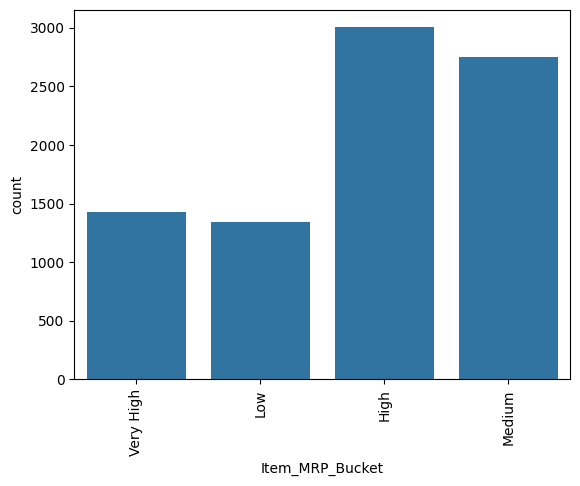

In [393]:
sns.countplot(data=data, x='Item_MRP_Bucket')
plt.xticks(rotation=90)

([0, 1], [Text(0, 0, 'Low fat'), Text(1, 0, 'Regular')])

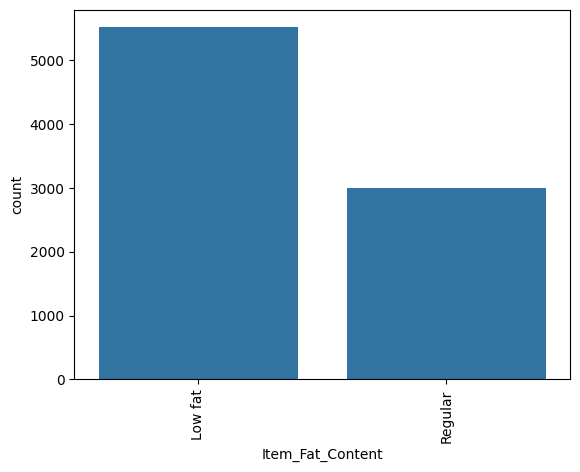

In [394]:
sns.countplot(data=data, x='Item_Fat_Content')
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'Dairy'),
  Text(1, 0, 'Soft Drinks'),
  Text(2, 0, 'Meat'),
  Text(3, 0, 'Fruits and Vegetables'),
  Text(4, 0, 'Household'),
  Text(5, 0, 'Baking Goods'),
  Text(6, 0, 'Snack Foods'),
  Text(7, 0, 'Frozen Foods'),
  Text(8, 0, 'Breakfast'),
  Text(9, 0, 'Health and Hygiene'),
  Text(10, 0, 'Hard Drinks'),
  Text(11, 0, 'Canned'),
  Text(12, 0, 'Breads'),
  Text(13, 0, 'Starchy Foods'),
  Text(14, 0, 'Others'),
  Text(15, 0, 'Seafood')])

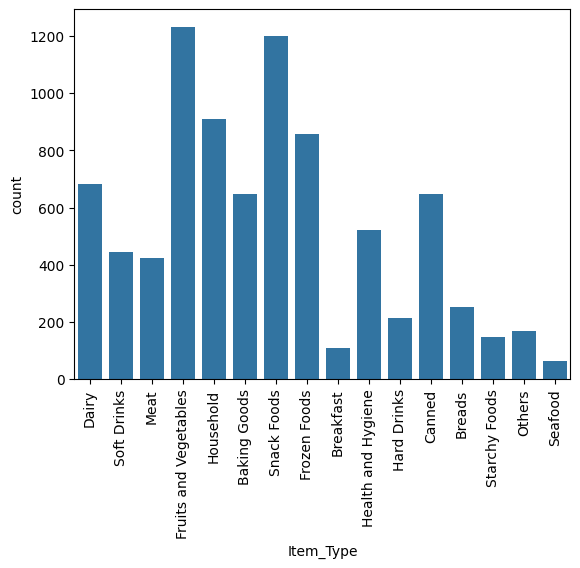

In [395]:
sns.countplot(data=data, x='Item_Type')
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'OUT049'),
  Text(1, 0, 'OUT018'),
  Text(2, 0, 'OUT010'),
  Text(3, 0, 'OUT013'),
  Text(4, 0, 'OUT027'),
  Text(5, 0, 'OUT045'),
  Text(6, 0, 'OUT017'),
  Text(7, 0, 'OUT046'),
  Text(8, 0, 'OUT035'),
  Text(9, 0, 'OUT019')])

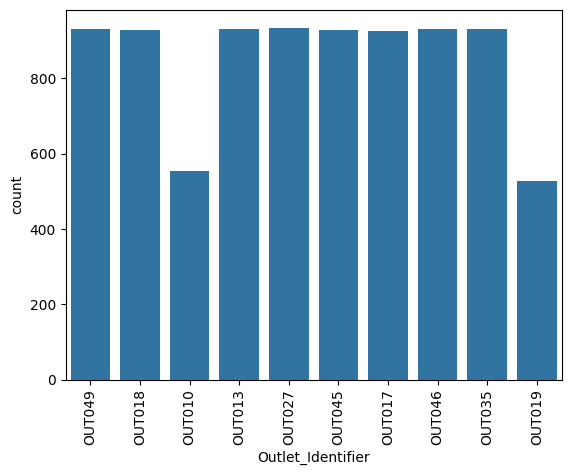

In [396]:
sns.countplot(data=data, x='Outlet_Identifier')
plt.xticks(rotation=90)

([0, 1, 2], [Text(0, 0, 'Medium'), Text(1, 0, 'High'), Text(2, 0, 'Small')])

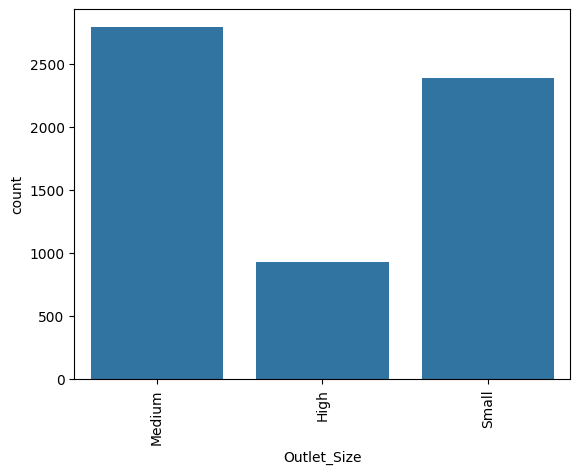

In [397]:
sns.countplot(data=data, x='Outlet_Size')
plt.xticks(rotation=90)

([0, 1, 2], [Text(0, 0, 'Tier 1'), Text(1, 0, 'Tier 3'), Text(2, 0, 'Tier 2')])

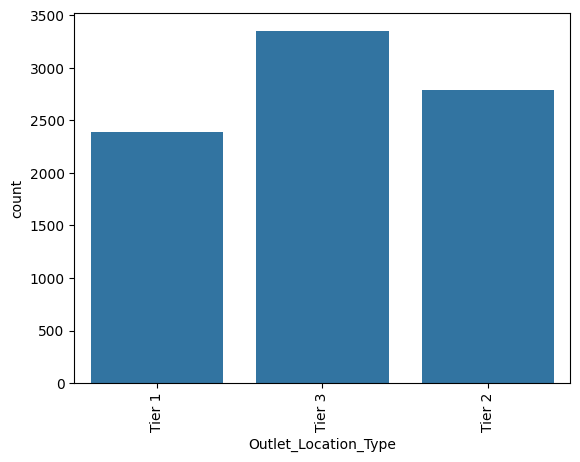

In [398]:
sns.countplot(data=data, x='Outlet_Location_Type')
plt.xticks(rotation=90)

([0, 1, 2, 3],
 [Text(0, 0, 'Supermarket Type1'),
  Text(1, 0, 'Supermarket Type2'),
  Text(2, 0, 'Grocery Store'),
  Text(3, 0, 'Supermarket Type3')])

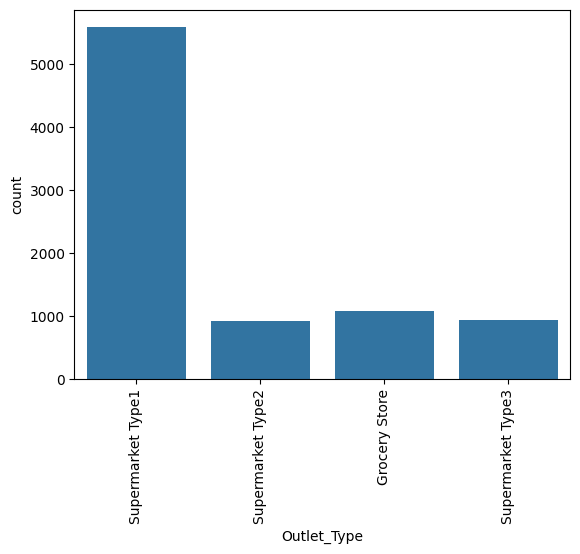

In [399]:
sns.countplot(data=data, x='Outlet_Type')
plt.xticks(rotation=90)

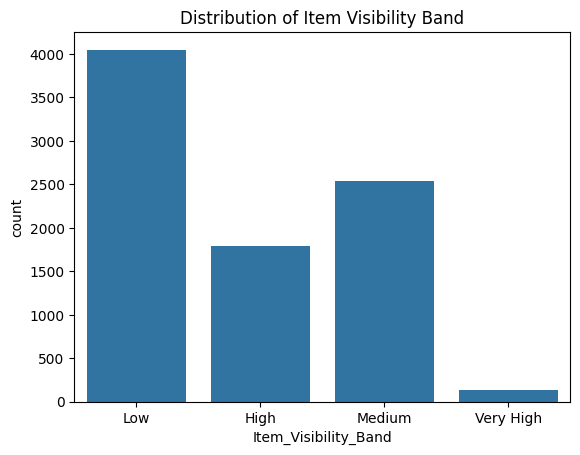

In [400]:

sns.countplot(data=data, x='Item_Visibility_Band')
plt.title('Distribution of Item Visibility Band')
plt.show()

**Numerical**

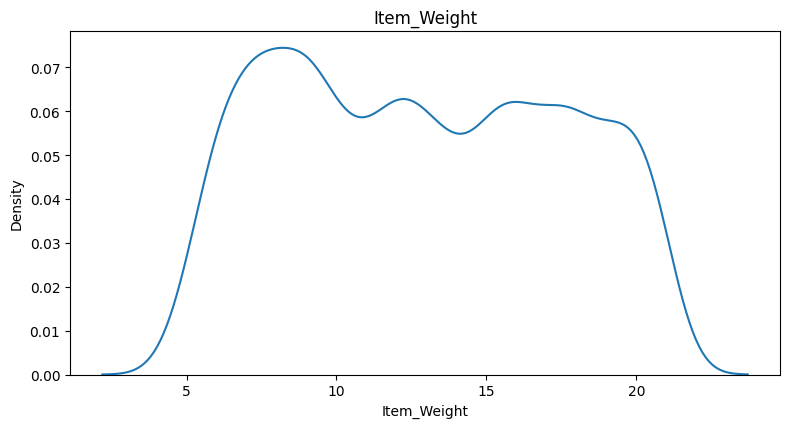

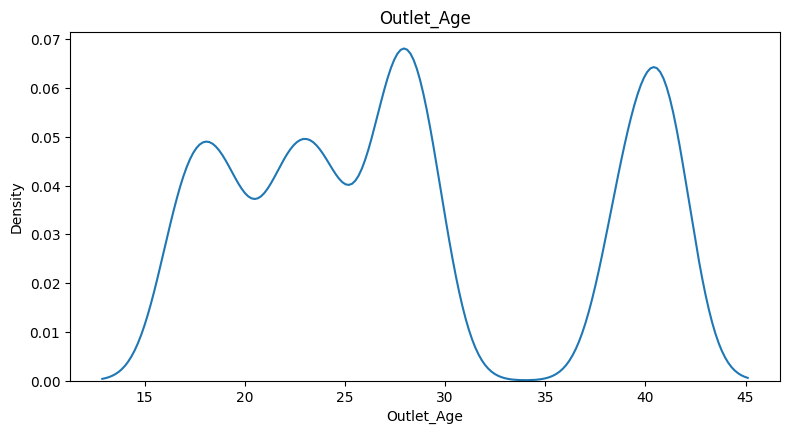

In [401]:
num=['Item_Weight','Outlet_Age']


for i,x in enumerate(num,1):
  plt.figure(figsize=(8,16))
  plt.subplot(4,1,i)
  sns.kdeplot(data[x])
  plt.title(x)
  plt.tight_layout()


In [402]:
data['Item_Weight'].skew()

np.float64(0.0824262091221237)

In [403]:
data['Outlet_Age'].skew()

np.float64(0.39664078591553986)

In [404]:
data['Outlet_Age']=np.log1p(data['Outlet_Age'])

# Bivariate Analysis

**Numerical**

<Axes: xlabel='Outlet_Age', ylabel='Item_Outlet_Sales'>

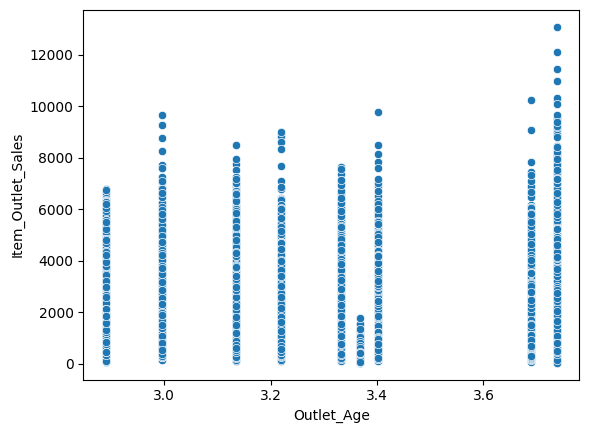

In [405]:
sns.scatterplot(x=data['Outlet_Age'],y=data['Item_Outlet_Sales'])

<Axes: xlabel='Item_Weight', ylabel='Item_Outlet_Sales'>

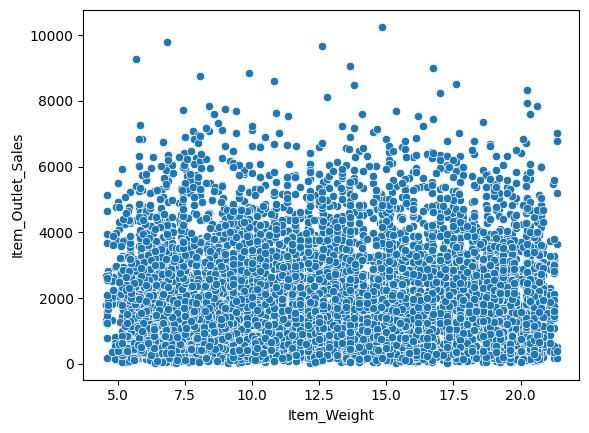

In [406]:
sns.scatterplot(x=data['Item_Weight'],y=data['Item_Outlet_Sales'])

<Axes: xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>

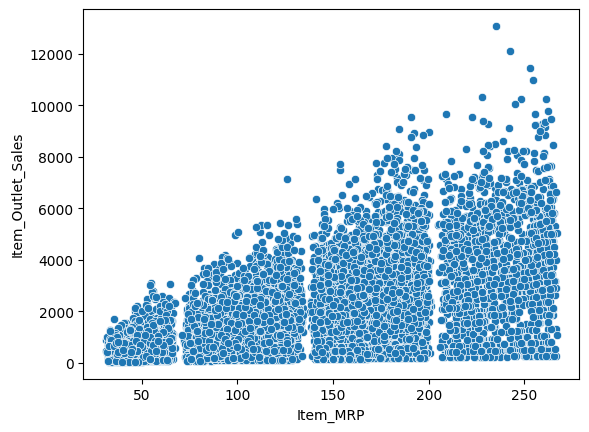

In [407]:
sns.scatterplot(x=data['Item_MRP'],y=data['Item_Outlet_Sales'])

**Categorical**

<Axes: xlabel='Item_MRP_Bucket', ylabel='Item_Outlet_Sales'>

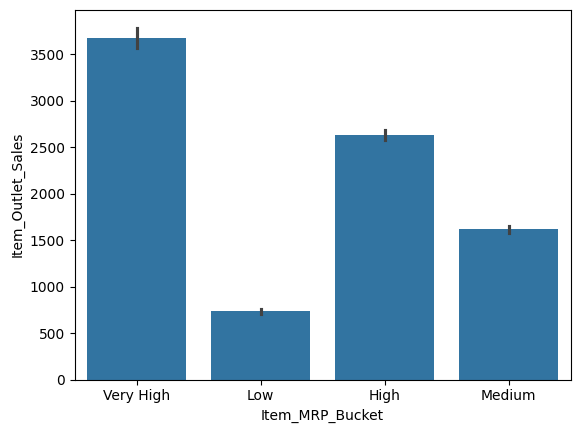

In [408]:
sns.barplot(x=data['Item_MRP_Bucket'],y=data['Item_Outlet_Sales'])

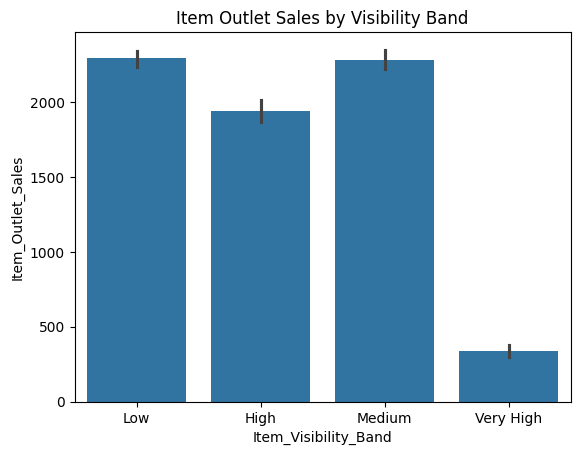

In [409]:

sns.barplot(data=data, x='Item_Visibility_Band', y='Item_Outlet_Sales')
plt.title('Item Outlet Sales by Visibility Band')

plt.show()

<Axes: xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>

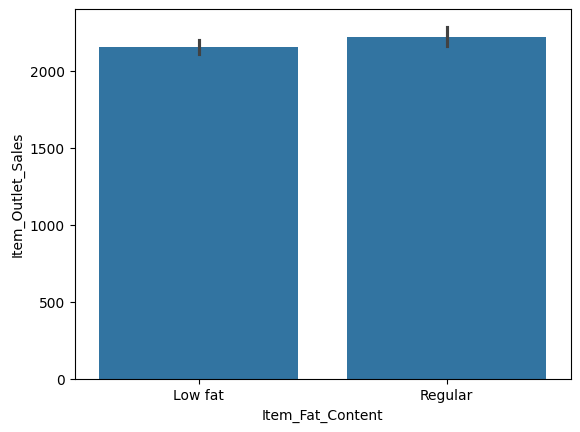

In [410]:
sns.barplot(x=data['Item_Fat_Content'],y=data['Item_Outlet_Sales'])

In [411]:
data2=data.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

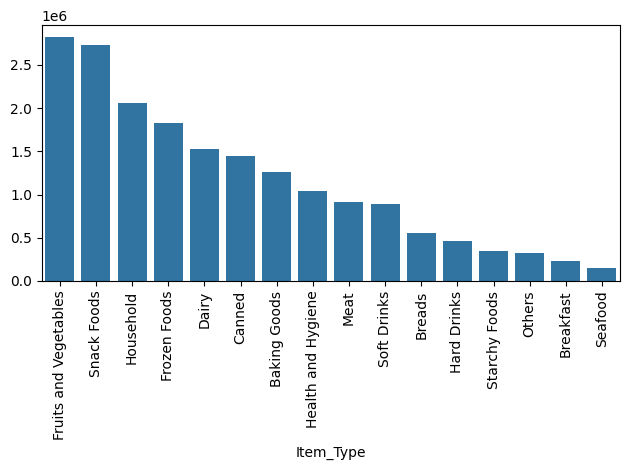

In [412]:

sns.barplot(x=data2.index,y=data2.values)
plt.xticks(rotation=90)

plt.tight_layout()

In [413]:
data1=(data.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum()).sort_values(ascending=False)
data1

,Item_Outlet_Sales
Outlet_Identifier,
OUT027,3.453926e+06
OUT035,2.268123e+06
OUT049,2.183970e+06
OUT017,2.167465e+06
OUT013,2.142664e+06
OUT046,2.118395e+06
OUT045,2.036725e+06
OUT018,1.851823e+06
OUT010,1.883402e+05


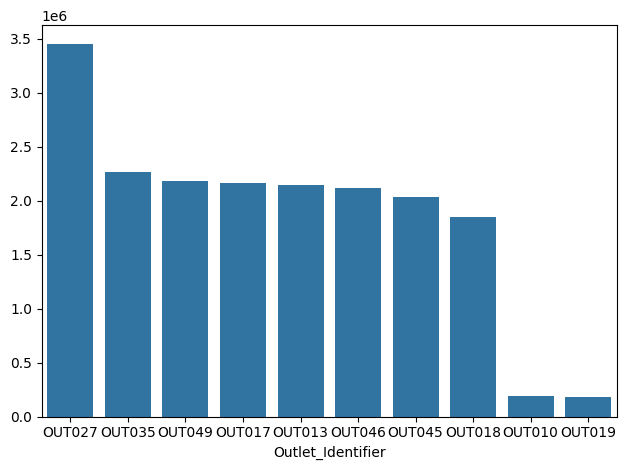

In [414]:


sns.barplot(x=data1.index,y=data1.values)
plt.tight_layout()


In [415]:
data4=data.groupby('Outlet_Size')['Item_Outlet_Sales'].sum().sort_values(ascending=False)
data4

,Item_Outlet_Sales
Outlet_Size,
Medium,7.489719e+06
Small,4.566212e+06
High,2.142664e+06


<Axes: xlabel='Outlet_Size'>

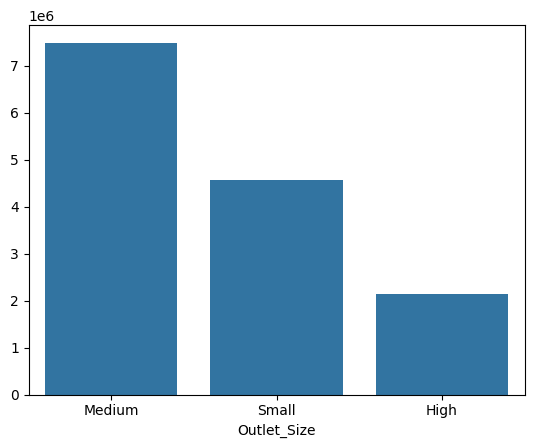

In [416]:
sns.barplot(x=data4.index,y=data4.values)

In [417]:
data5=data.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)
data5

,Item_Outlet_Sales
Outlet_Location_Type,
Tier 3,7.636753e+06
Tier 2,6.472314e+06
Tier 1,4.482059e+06


<Axes: xlabel='Outlet_Location_Type'>

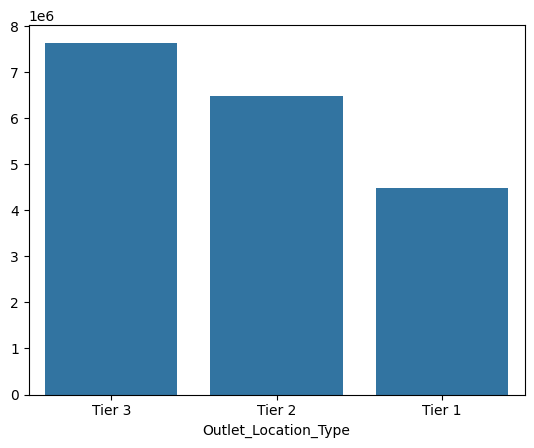

In [418]:
sns.barplot(x=data5.index,y=data5.values)

In [419]:
data6=data.groupby('Outlet_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)
data6

,Item_Outlet_Sales
Outlet_Type,
Supermarket Type1,1.291734e+07
Supermarket Type3,3.453926e+06
Supermarket Type2,1.851823e+06
Grocery Store,3.680343e+05


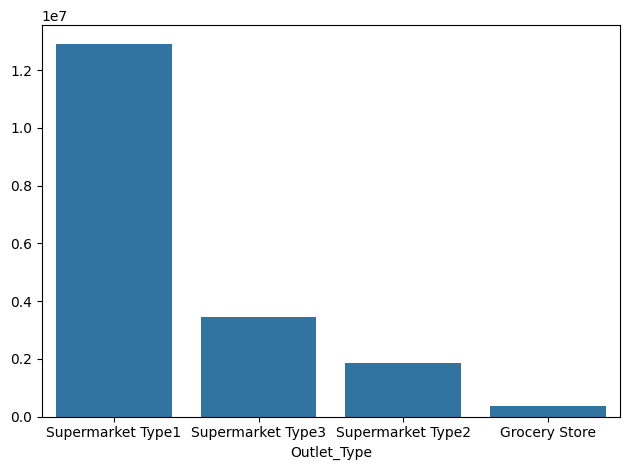

In [420]:
sns.barplot(x=data6.index,y=data6.values)
plt.tight_layout()

# Outlier Detection

<Axes: ylabel='Item_Weight'>

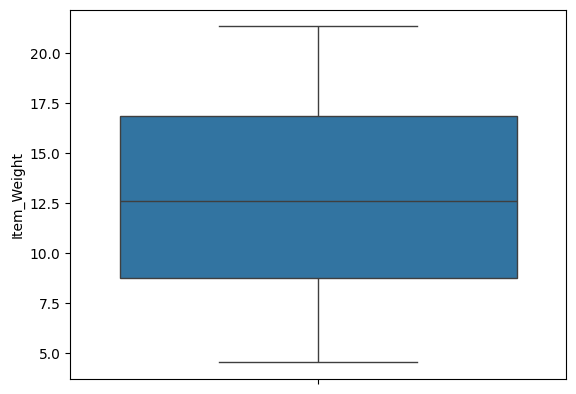

In [421]:
sns.boxplot(data['Item_Weight'])

<Axes: ylabel='Outlet_Age'>

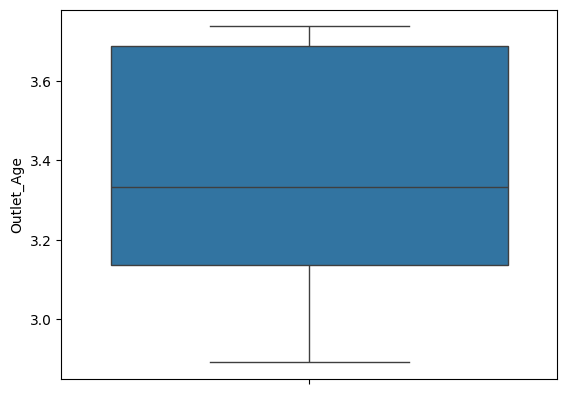

In [422]:
sns.boxplot(data['Outlet_Age'])

# Splitting features and Target

In [423]:
data['Item_Outlet_Sales']=np.log1p(data['Item_Outlet_Sales'])

In [424]:
x=data.drop(columns='Item_Outlet_Sales')
x

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Age,Item_MRP_Bucket,Item_Visibility_Band
0,9.300,Low fat,0.016047,Dairy,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3.332205,Very High,Low
1,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,2.890372,Low,Low
2,17.500,Low fat,0.016760,Meat,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,3.332205,High,Low
3,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,NaN,Tier 3,Grocery Store,3.367296,High,Low
4,8.930,Low fat,0.000000,Household,53.8614,OUT013,High,Tier 3,Supermarket Type1,3.688879,Low,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,Low fat,0.056783,Snack Foods,214.5218,OUT013,High,Tier 3,Supermarket Type1,3.688879,Very High,Medium
8519,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,NaN,Tier 2,Supermarket Type1,3.218876,Medium,Low
8520,10.600,Low fat,0.035186,Health and Hygiene,85.1224,OUT035,Small,Tier 2,Supermarket Type1,3.135494,Medium,Low
8521,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,Medium,Tier 3,Supermarket Type2,2.890372,Medium,High


In [425]:
y=data['Item_Outlet_Sales']
y

,Item_Outlet_Sales
0,8.225808
1,6.096776
2,7.648868
3,6.597664
4,6.903451
...,...
8518,7.929984
8519,6.310436
8520,7.085159
8521,7.521100


In [426]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [427]:
ohe_data=['Item_Fat_Content','Item_Type','Outlet_Identifier','Outlet_Type','Outlet_Location_Type']
ordinal_data=['Outlet_Size','Item_MRP_Bucket','Item_Visibility_Band']


In [428]:
num

['Item_Weight', 'Outlet_Age']

In [429]:
trf = ColumnTransformer(transformers=[
    ('Item_Weight_pipeline', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]), ['Item_Weight']),

    ('Outlet_Size_pipeline', Pipeline([ # Combined Imputer and OrdinalEncoder for Outlet_Size
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(categories=[['Small', 'Medium', "High"],]))
    ]), ['Outlet_Size']),

    ('Scaling_other_num', StandardScaler(), ['Item_Visibility', 'Outlet_Age']),

    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Type', 'Outlet_Location_Type']),

    ('Item_MRP_+_Visibility_pipeline', Pipeline([
        ('ordinal', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High'], ['Low', 'Medium', 'High', 'Very High']]))
    ]), ['Item_MRP_Bucket','Item_Visibility_Band'])

], remainder='drop')

trf.set_output(transform="pandas")

ColumnTransformer(transformers=[('Item_Weight_pipeline',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Item_Weight']),
                                ('Outlet_Size_pipeline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Small',
                                                                              'Medium',
                                                                              'High']]))]),
                                 ['Outlet_Size']),
                                ('Scaling_other_num', Stan...
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Item_Fat_Content', 'Item_Type',
                                  'Outlet_Identifier', 'Outlet_Type',
                                  'Outlet_Location_Type']),
                                ('Item_MRP_+_Visibility_pipeline',
                                 Pipeline(steps=[('ordinal',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Item_MRP_Bucket', 'Item_Visibility_Band'])])

In [430]:


pipe_lr=Pipeline([
    ('trf',trf),
    ('lr',LinearRegression())
])
pipe_lr.fit(x_train,y_train)

Pipeline(steps=[('trf',
                 ColumnTransformer(transformers=[('Item_Weight_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Item_Weight']),
                                                 ('Outlet_Size_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Small',
                                                                                               'Medium',
                                                                                               'High']]))]),
                                                  ['Outlet_Size']),
                                                 ('...
                                                                sparse_output=False),
                                                  ['Item_Fat_Content',
                                                   'Item_Type',
                                                   'Outlet_Identifier',
                                                   'Outlet_Type',
                                                   'Outlet_Location_Type']),
                                                 ('Item_MRP_+_Visibility_pipeline',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High'],
                                                                                              ['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Item_MRP_Bucket',
                                                   'Item_Visibility_Band'])])),
                ('lr', LinearRegression())])

In [431]:
y_pred_lr=pipe_lr.predict(x_test)
print("Linear Regression: ",r2_score(y_test,y_pred_lr))

Linear Regression:  0.7230685956380715


In [432]:
pipe_svr=Pipeline([
    ('trf',trf),
    ('svr',SVR())
])
pipe_svr.fit(x_train,y_train)

Pipeline(steps=[('trf',
                 ColumnTransformer(transformers=[('Item_Weight_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Item_Weight']),
                                                 ('Outlet_Size_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Small',
                                                                                               'Medium',
                                                                                               'High']]))]),
                                                  ['Outlet_Size']),
                                                 ('...
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Item_Fat_Content',
                                                   'Item_Type',
                                                   'Outlet_Identifier',
                                                   'Outlet_Type',
                                                   'Outlet_Location_Type']),
                                                 ('Item_MRP_+_Visibility_pipeline',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High'],
                                                                                              ['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Item_MRP_Bucket',
                                                   'Item_Visibility_Band'])])),
                ('svr', SVR())])

In [433]:
y_pred_svr=pipe_svr.predict(x_test)
print("SVR: ",r2_score(y_test,y_pred_svr))


SVR:  0.7206624470455101


In [434]:
pipe_xgb=Pipeline([
    ('trf',trf),
    ('xgb',XGBRegressor())
])

pipe_xgb.fit(x_train,y_train)

Pipeline(steps=[('trf',
                 ColumnTransformer(transformers=[('Item_Weight_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Item_Weight']),
                                                 ('Outlet_Size_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Small',
                                                                                               'Medium',
                                                                                               'High']]))]),
                                                  ['Outlet_Size']),
                                                 ('...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [435]:
y_pred_xgb=pipe_xgb.predict(x_test)
print("XG Boost: ",r2_score(y_test,y_pred_xgb))

XG Boost:  0.694822948757646


In [436]:
pipe_sgd=Pipeline([
    ('trf',trf),
    ('sgd',SGDRegressor())
])
pipe_sgd.fit(x_train,y_train)

Pipeline(steps=[('trf',
                 ColumnTransformer(transformers=[('Item_Weight_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Item_Weight']),
                                                 ('Outlet_Size_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Small',
                                                                                               'Medium',
                                                                                               'High']]))]),
                                                  ['Outlet_Size']),
                                                 ('...
                                                                sparse_output=False),
                                                  ['Item_Fat_Content',
                                                   'Item_Type',
                                                   'Outlet_Identifier',
                                                   'Outlet_Type',
                                                   'Outlet_Location_Type']),
                                                 ('Item_MRP_+_Visibility_pipeline',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High'],
                                                                                              ['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Item_MRP_Bucket',
                                                   'Item_Visibility_Band'])])),
                ('sgd', SGDRegressor())])

In [437]:
y_pred_sgd=pipe_sgd.predict(x_test)
print("SGD: ",r2_score(y_test,y_pred_sgd))

SGD:  0.7207919779287764


In [438]:
pipe_dt=Pipeline([
    ('trf',trf),
    ('dt',DecisionTreeRegressor())
])

pipe_dt.fit(x_train,y_train)

Pipeline(steps=[('trf',
                 ColumnTransformer(transformers=[('Item_Weight_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Item_Weight']),
                                                 ('Outlet_Size_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Small',
                                                                                               'Medium',
                                                                                               'High']]))]),
                                                  ['Outlet_Size']),
                                                 ('...
                                                                sparse_output=False),
                                                  ['Item_Fat_Content',
                                                   'Item_Type',
                                                   'Outlet_Identifier',
                                                   'Outlet_Type',
                                                   'Outlet_Location_Type']),
                                                 ('Item_MRP_+_Visibility_pipeline',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High'],
                                                                                              ['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Item_MRP_Bucket',
                                                   'Item_Visibility_Band'])])),
                ('dt', DecisionTreeRegressor())])

In [439]:
y_pred_dt=pipe_dt.predict(x_test)
print("Decision Tree: ",r2_score(y_test,y_pred_dt))

Decision Tree:  0.4677102161474531


In [440]:
pipe_forest=Pipeline([
    ('trf',trf),
    ('forest',RandomForestRegressor())
])
pipe_forest.fit(x_train,y_train)

Pipeline(steps=[('trf',
                 ColumnTransformer(transformers=[('Item_Weight_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Item_Weight']),
                                                 ('Outlet_Size_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Small',
                                                                                               'Medium',
                                                                                               'High']]))]),
                                                  ['Outlet_Size']),
                                                 ('...
                                                                sparse_output=False),
                                                  ['Item_Fat_Content',
                                                   'Item_Type',
                                                   'Outlet_Identifier',
                                                   'Outlet_Type',
                                                   'Outlet_Location_Type']),
                                                 ('Item_MRP_+_Visibility_pipeline',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High'],
                                                                                              ['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Item_MRP_Bucket',
                                                   'Item_Visibility_Band'])])),
                ('forest', RandomForestRegressor())])

In [441]:
y_pred_forest=pipe_forest.predict(x_test)
print("Random Forest: ",r2_score(y_test,y_pred_forest))

Random Forest:  0.698693854674378


In [442]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__max_depth': [3, 5, 7],
    'xgb__subsample': [0.7, 0.8, 0.9]
}

grid_search = GridSearchCV(pipe_xgb, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2)
grid_search.fit(x_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best R2 score: {grid_search.best_score_}")

y_pred_xgb_tuned = grid_search.predict(x_test)
print(f"Tuned XG Boost R2 score on test set: {r2_score(y_test, y_pred_xgb_tuned)}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best parameters: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Best R2 score: 0.7160666700028057
Tuned XG Boost R2 score on test set: 0.730958670328022


In [443]:
param_grid_rf = {
    'forest__n_estimators': [100, 200, 300],
    'forest__max_depth': [5, 10, 15],
    'forest__min_samples_leaf': [1, 2, 4],
    'forest__min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(pipe_forest, param_grid_rf, cv=3, scoring='r2', n_jobs=-1, verbose=2)
grid_search_rf.fit(x_train, y_train)

print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best R2 score for Random Forest: {grid_search_rf.best_score_}")

y_pred_rf_tuned = grid_search_rf.predict(x_test)
print(f"Tuned Random Forest R2 score on test set: {r2_score(y_test, y_pred_rf_tuned)}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best parameters for Random Forest: {'forest__max_depth': 5, 'forest__min_samples_leaf': 1, 'forest__min_samples_split': 10, 'forest__n_estimators': 300}
Best R2 score for Random Forest: 0.7147555358635267
Tuned Random Forest R2 score on test set: 0.7307660562328335
